# Positioning task #1



## Introduction

In this tutorial, we will explore a common failure in machine learning: the task of object positioning using Convolutional Neural Networks (CNNs). Although this is a very common task, we will see that our training procedure ultimately fails. We invite you to solve the issue in the training process!

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'  # suppress TensorFlow warnings
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # use CPU only, uncomment this line to use GPU

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2

import tensorflow as tf
# fix random seed for reproducibility
seed = 0
tf.random.set_seed(seed)
np.random.seed(seed)

2024-04-29 09:48:27.287816: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-29 09:48:27.287857: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-29 09:48:27.287888: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
tf.test.is_gpu_available()

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


True

Additionally, let's inspect the images in the loaded dataset. To achieve this, we will display the first 36 images along with their positions from both the training and test data.

Our goal is to train the neural network model to predict the positions of the shapes (circles, triangles, and squares) in the images.

## Marco's problem

### Load dataset

First, we will load a prepared dataset that includes both training and test data.

In [3]:
def load_data(train_data_path, test_data_path):
    traindata = np.load(train_data_path)
    testdata = np.load(test_data_path)
    X_train = traindata['img']
    y_train = traindata['position']
    X_test = testdata['img']
    y_test = testdata['position']
    return (X_train, y_train), (X_test, y_test)

As the image dataset is in 8-bit unsigned integer format (`uint8`, with values ranging from 0 to 255), it is necessary to convert it to `float32` by normalizing the values. This conversion allows neural networks to process the data.

This time, `X_train` and `X_test` are images and `y_train` and `y_test` are positions of the shapes. 

In [4]:
label_name = ['circle', 'triangle', 'square']
(X_train, y_train), (X_test, y_test) = load_data('../data/positioning_1_train.npz', '../data/positioning_test.npz')

# normalize image data (uint8 [0-255] -> float32 [0.0-1.0])
X_train = (X_train / 255).astype(np.float32)
X_test = (X_test / 255.).astype(np.float32)

In [5]:
img_rows, img_cols, img_channel = X_train.shape[1:4] # size of height, width, channels
num_axis = 2 # number of axis for positioning

Let's examine the size of the loaded dataset.

In [6]:
print('X_train.shape: ', X_train.shape)
print('Y_train.shape: ', y_train.shape)
print('X_test.shape:  ', X_test.shape)
print('Y_test.shape:  ', y_test.shape)

X_train.shape:  (60000, 36, 36, 3)
Y_train.shape:  (60000, 2)
X_test.shape:   (10000, 36, 36, 3)
Y_test.shape:   (10000, 2)


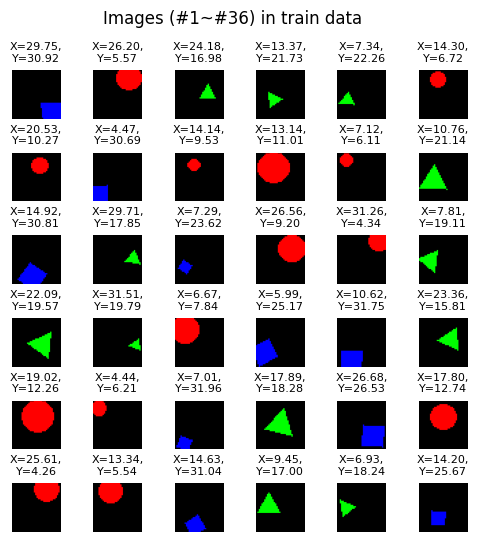

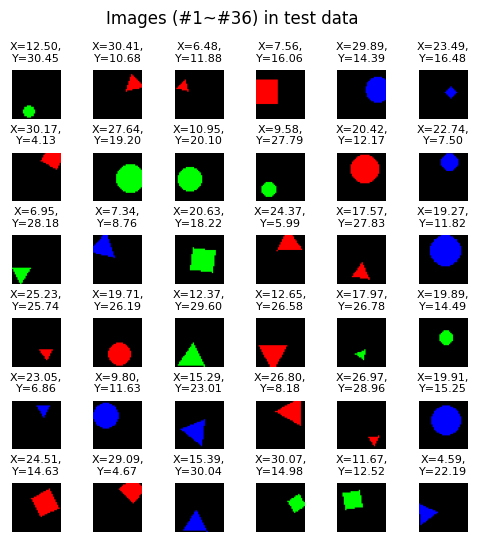

In [7]:
def plot_image(X, y):
    plt.figure(figsize=(6,6))
    for i in range(6*6):
        plt.subplot(6,6,i+1)
        plt.imshow(X[i], cmap='gray')  # cmap='gray' displays an image in black and white for monotone images and in color for rgb images. 
        plt.axis('off')
        plt.title(f'X={y[i][0]:.2f},\nY={y[i][1]:.2f}', fontsize=8) # Top left is (0,0)
    plt.subplots_adjust(wspace=0.4, hspace=0.7)

plot_image(X_train, y_train)
plt.suptitle('Images (#1~#36) in train data')
plt.show()

plot_image(X_test, y_test)
plt.suptitle('Images (#1~#36) in test data')
plt.show()

With those necessary numbers, finally we can define our CNN model. 

### Define the model
The next step is to define our neural network model. To create a CNN model for positioning tasks, we need to set up the model to be suitable for the size of the processed images, including their height, width, and the number of channels (e.g., RGB), as well as the coordinates of the shapes. 

In [8]:
img_rows, img_cols, img_channel = X_train.shape[1:4] # size of height, width, channels
num_axis = 2 # number of axis for positioning

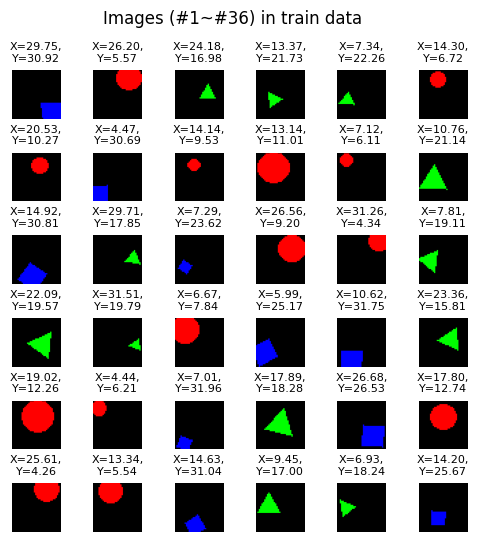

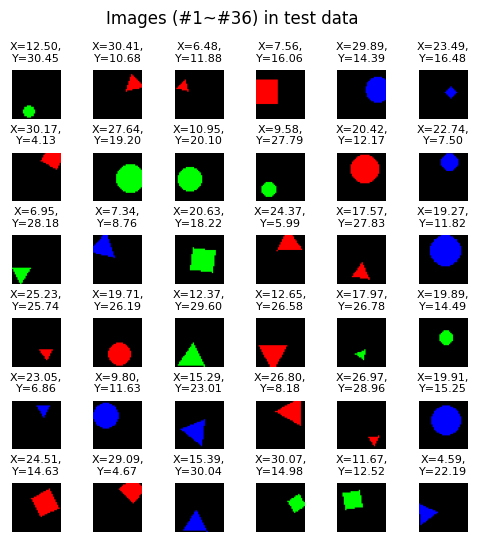

In [9]:
def plot_image(X, y):
    plt.figure(figsize=(6,6))
    for i in range(6*6):
        plt.subplot(6,6,i+1)
        plt.imshow(X[i], cmap='gray')  # cmap='gray' displays an image in black and white for monotone images and in color for rgb images. 
        plt.axis('off')
        plt.title(f'X={y[i][0]:.2f},\nY={y[i][1]:.2f}', fontsize=8) # Top left is (0,0)
    plt.subplots_adjust(wspace=0.4, hspace=0.7)

plot_image(X_train, y_train)
plt.suptitle('Images (#1~#36) in train data')
plt.show()

plot_image(X_test, y_test)
plt.suptitle('Images (#1~#36) in test data')
plt.show()

With those necessary numbers, finally we can define our CNN model. 

In [10]:
def get_model(input_shape, num_axis):
    model = tf.keras.Sequential([
            tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", input_shape=input_shape),
            tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dense(num_axis, activation="linear"),
        ])
    return model

model = get_model(input_shape=(img_rows, img_cols, img_channel), num_axis=num_axis)
model.compile(optimizer=tf.keras.optimizers.Adadelta(),
              loss='mean_squared_error',
              metrics=['mean_absolute_error'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 34, 34, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 17, 17, 32)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 9248)              0         
                                                                 
 dense (Dense)               (None, 128)               1183872   
                                                                 
 dense_1 (Dense)             (None, 2)                 258       
                                                                 
Total params: 1185026 (4.52 MB)
Trainable params: 1185026 (4.52 MB)
Non-trainable params: 0 (0.00 Byte)
__________________

### Training

Now let's train our model with the loaded images!

In [11]:
epochs = 10
batch_size = 32
result = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size)

print(f'train loss: {result.history["loss"][-1]}, train error: {result.history["mean_absolute_error"][-1]} pixels')

Epoch 1/10
1875/1875 [==============================] - 18s 9ms/step - loss: 205.4206 - mean_absolute_error: 11.7246
Epoch 2/10
1875/1875 [==============================] - 16s 9ms/step - loss: 32.3639 - mean_absolute_error: 4.6391
Epoch 3/10
1875/1875 [==============================] - 15s 8ms/step - loss: 16.7205 - mean_absolute_error: 3.0646
Epoch 4/10
1875/1875 [==============================] - 14s 8ms/step - loss: 11.1337 - mean_absolute_error: 2.4493
Epoch 5/10
1875/1875 [==============================] - 15s 8ms/step - loss: 9.0542 - mean_absolute_error: 2.2274
Epoch 6/10
1875/1875 [==============================] - 13s 7ms/step - loss: 7.7531 - mean_absolute_error: 2.0632
Epoch 7/10
1875/1875 [==============================] - 14s 8ms/step - loss: 6.7635 - mean_absolute_error: 1.9258
Epoch 8/10
1875/1875 [==============================] - 16s 9ms/step - loss: 5.9798 - mean_absolute_error: 1.8089
Epoch 9/10
1875/1875 [==============================] - 16s 9ms/step - loss: 5.343

### Problem

The error in prediction on the training data is much small.
Then, let's evaluate it using the test data.

In [12]:
test_loss, test_metric = model.evaluate(X_test, y_test)
print(f'test loss: {test_loss}, test error: {test_metric} pixels')

313/313 [==============================] - 2s 6ms/step - loss: 16.8293 - mean_absolute_error: 3.0646
test loss: 16.829296112060547, test error: 3.0646138191223145 pixels


The error in the test data is much higher. 
This suggests that generalization is not working well.
Let's consider the reasons for such results and find a solution to achieve high performance on test data.

## Solutions

### Load dataset (load information for EDA)

In [13]:
def load_data(train_data_path, test_data_path):
    traindata = np.load(train_data_path)
    testdata = np.load(test_data_path)
    X_train = traindata['img']
    y_train = traindata['position']
    shape_train = traindata['label']
    X_test = testdata['img']
    y_test = testdata['position']
    shape_test = testdata['label']
    return (X_train, y_train, shape_train), (X_test, y_test, shape_test)

In [14]:
label_name = ['circle', 'triangle', 'square']
(X_train, y_train, shape_train), (X_test, y_test, shape_test) = load_data('../data/positioning_1_train.npz', '../data/positioning_test.npz')

# normalize image data (uint8 [0-255] -> float32 [0.0-1.0])
X_train = (X_train / 255).astype(np.float32)
X_test = (X_test / 255.).astype(np.float32)

In [15]:
img_rows, img_cols, img_channel = X_train.shape[1:4] # size of height, width, channels
num_axis = 2 # number of axis for positioning

In [16]:
print('X_train.shape: ', X_train.shape)
print('Y_train.shape: ', y_train.shape)
print('shape_train: ', shape_train.shape)
print('X_test.shape:  ', X_test.shape)
print('Y_test.shape:  ', y_test.shape)
print('shape_test: ', shape_test.shape)

X_train.shape:  (60000, 36, 36, 3)
Y_train.shape:  (60000, 2)
shape_train:  (60000,)
X_test.shape:   (10000, 36, 36, 3)
Y_test.shape:   (10000, 2)
shape_test:  (10000,)


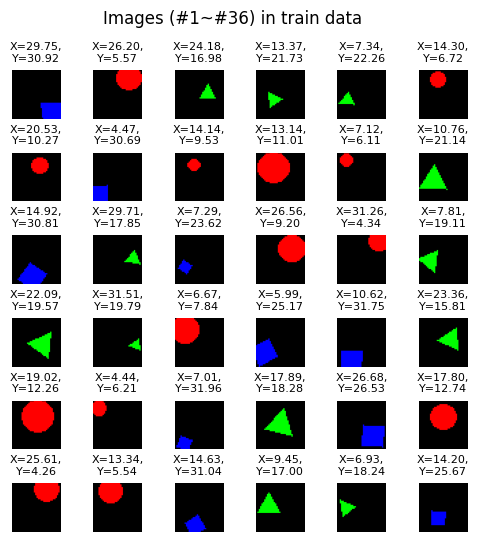

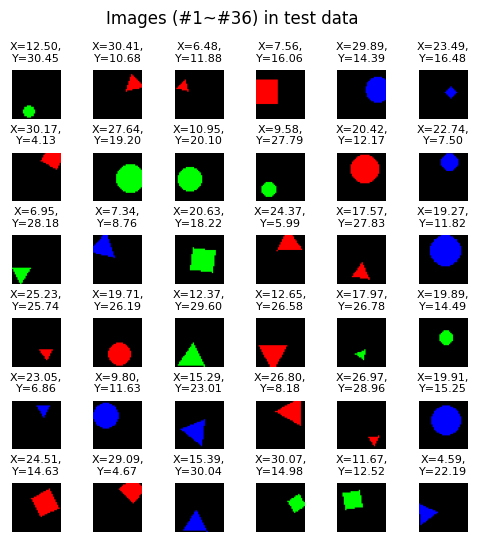

In [17]:
def plot_image(X, y):
    plt.figure(figsize=(6,6))
    for i in range(6*6):
        plt.subplot(6,6,i+1)
        plt.imshow(X[i], cmap='gray')  # cmap='gray' displays an image in black and white for monotone images and in color for rgb images. 
        plt.axis('off')
        plt.title(f'X={y[i][0]:.2f},\nY={y[i][1]:.2f}', fontsize=8) # Top left is (0,0)
    plt.subplots_adjust(wspace=0.4, hspace=0.7)

plot_image(X_train, y_train)
plt.suptitle('Images (#1~#36) in train data')
plt.show()

plot_image(X_test, y_test)
plt.suptitle('Images (#1~#36) in test data')
plt.show()

### EDA

Data is the same as data in Excercise 1, so that it have some features which are analyzed:
<ul>
    <li> Shape distribution is balance
    <li> Color is only 1 channels of RGB for train, but 3 for test
    <li> Position distribution is Normal distribution with mean is center for all dataset
    <li> Brightness distribution is different for dataset/shape
</ul>
<br>
Need to analyze:
<ul>
    <li> Cause we will transfer image to Black and White, so no need to analyze about color anymore
    <li> Only relation about center - shape
</ul>

In [18]:
def create_center_map(y, shape, shape_filter=""):

    y_check = []
    for index in range(len(shape)):
        if (shape_filter == "") or (shape[index]==shape_filter):
            y_check.append(y[index])

    heatmap = np.zeros((36,36))
    for y in y_check:
        try:
            y = np.round(y).astype('uint8')
            heatmap[y[1], y[0]] +=1
        except:
            print(y)
        

    return heatmap

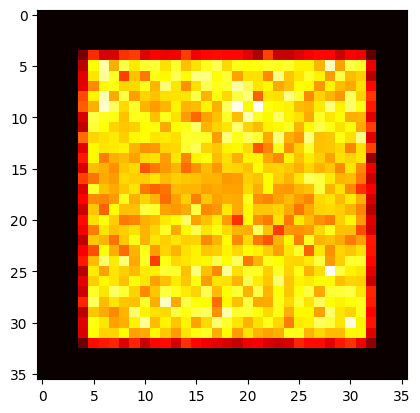

In [19]:
plt.imshow(create_center_map(y_train, shape_train), cmap='hot', interpolation='nearest')

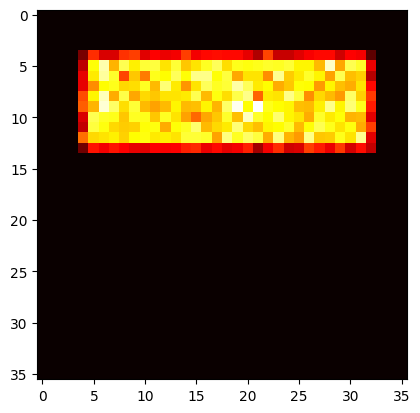

In [20]:
plt.imshow(create_center_map(y_train, shape_train, shape_filter=0), cmap='hot', interpolation='nearest')

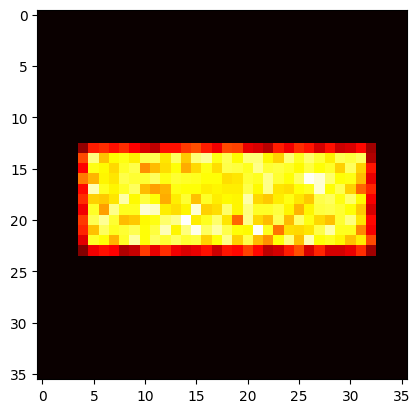

In [21]:
plt.imshow(create_center_map(y_train, shape_train, shape_filter=1), cmap='hot', interpolation='nearest')

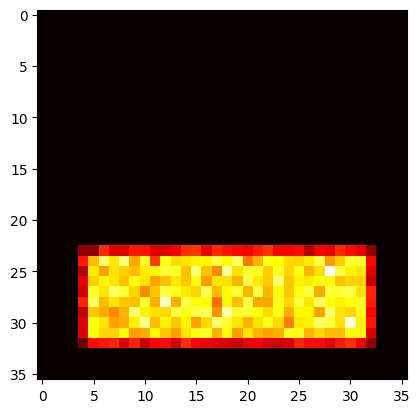

In [22]:
plt.imshow(create_center_map(y_train, shape_train, shape_filter=2), cmap='hot', interpolation='nearest')

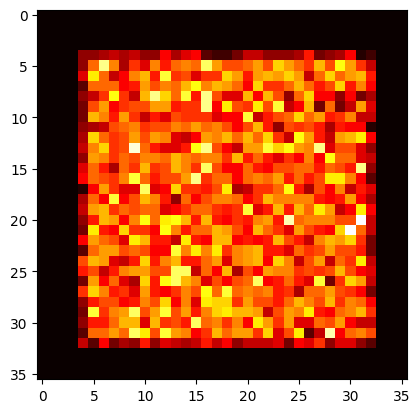

In [23]:
plt.imshow(create_center_map(y_test, shape_test), cmap='hot', interpolation='nearest')

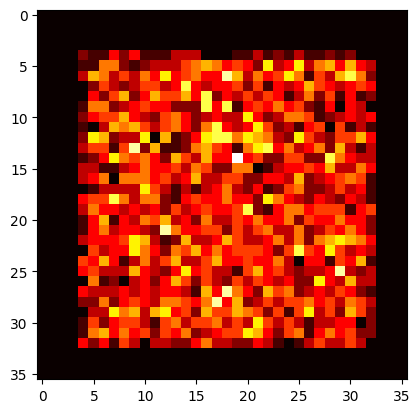

In [24]:
plt.imshow(create_center_map(y_test, shape_test, shape_filter=0), cmap='hot', interpolation='nearest')

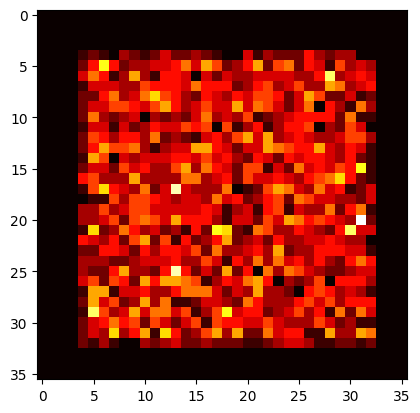

In [25]:
plt.imshow(create_center_map(y_test, shape_test, shape_filter=1), cmap='hot', interpolation='nearest')

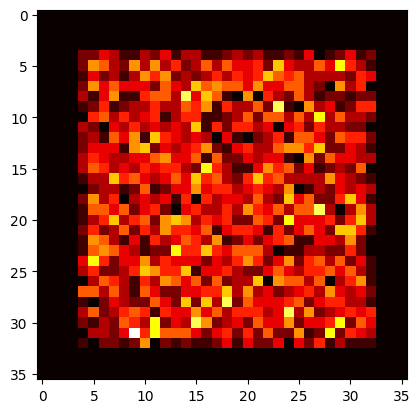

In [26]:
plt.imshow(create_center_map(y_test, shape_test, shape_filter=2), cmap='hot', interpolation='nearest')

### New data

In [49]:
def create_data(X, y, shape):
    """Create shape for """

    X_new = []
    y_new = []
    shape_new = []

    for x_index, x in enumerate(X):

        label = y[x_index]
        shape_type = shape[x_index]
        
        if shape_type == 0:
            bonus_lst = [10, 20]
        elif shape_type == 1:
            bonus_lst = [10, -10]
        elif shape_type == 2:
            bonus_lst = [-10, -20]
        else:
            raise ValueError('Unknown shape type - Please check dataset again')

        x_expand = np.zeros((76, 76, 3))
        x_expand[20:56, 20:56] = x

        X_new.append(x)
        y_new.append(label)
        shape_new.append(shape_type)

        for bonus in bonus_lst:
            if bonus == 10:
                x_aug = x_expand[10:46, 20:56]
                label_aug = np.array([label[0], label[1]+10])
            elif bonus == -10:
                x_aug = x_expand[30:66, 20:56]
                label_aug = np.array([label[0], label[1]-10])
            elif bonus == 20:
                x_aug = x_expand[0:36, 20:56]
                label_aug = np.array([label[0], label[1]+20])
            elif bonus == -20:
                x_aug = x_expand[40:76, 20:56]
                label_aug = np.array([label[0], label[1]-20])

            X_new.append(x_aug)
            y_new.append(label_aug)
            shape_new.append(shape_type)

    return X_new, y_new, shape_new

In [50]:
X_train_new, y_train_new, shape_train_new = create_data(X_train, y_train, shape_train)

In [51]:
y_train_new[0]

array([29.74563466, 30.9181584 ])

In [52]:
y_train_new[1]

array([29.74563466, 20.9181584 ])

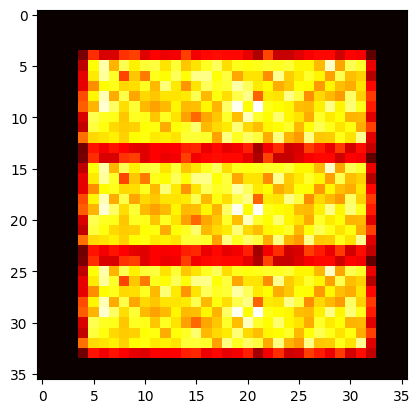

In [53]:
plt.imshow(create_center_map(y_train_new, shape_train_new, shape_filter=0), cmap='hot', interpolation='nearest')

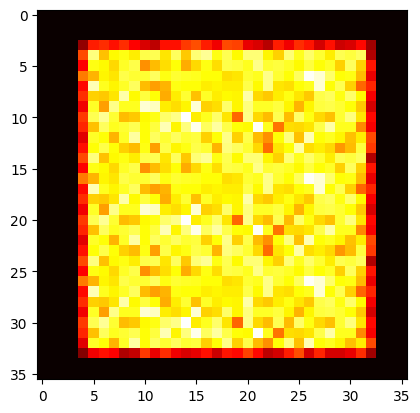

In [54]:
plt.imshow(create_center_map(y_train_new, shape_train_new, shape_filter=1), cmap='hot', interpolation='nearest')

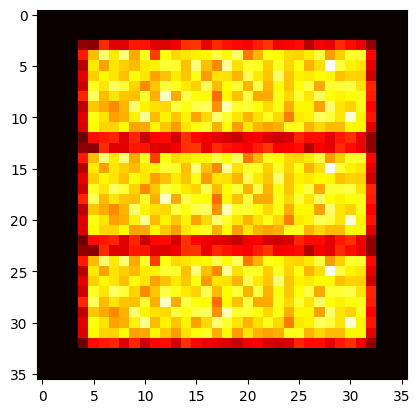

In [55]:
plt.imshow(create_center_map(y_train_new, shape_train_new, shape_filter=2), cmap='hot', interpolation='nearest')

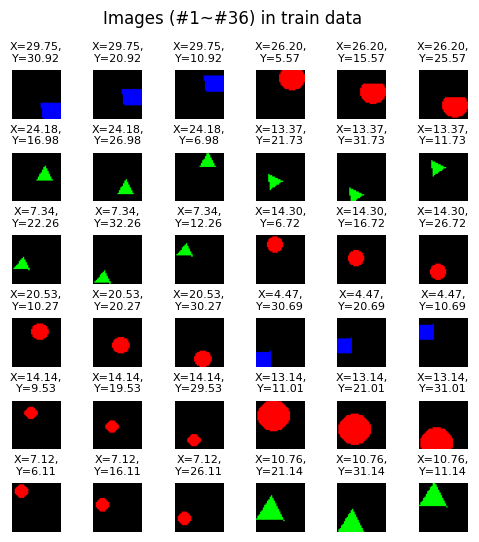

In [56]:
plot_image(X_train_new, y_train_new)
plt.suptitle('Images (#1~#36) in train data')
plt.show()

### Standarize data

In [57]:
X_train_standarize = []
X_test_standarize = []

for x in X_train_new:
    x = x*255.0
    x = x.astype('uint8')
    x = cv2.cvtColor(x, cv2.COLOR_RGB2GRAY)
    x = x > 0
    X_train_standarize.append(x)

for x in X_test:
    x = x*255.0
    x = x.astype('uint8')
    x = cv2.cvtColor(x, cv2.COLOR_RGB2GRAY)
    x = x > 0
    X_test_standarize.append(x)

X_train_standarize = np.array(X_train_standarize)
X_test_standarize = np.array(X_test_standarize)

y_train_standarize = np.array(y_train_new)

### Train data

#### Marco's model

In [58]:
def get_model(input_shape, num_axis):
    model = tf.keras.Sequential([
            tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", input_shape=input_shape),
            tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dense(num_axis, activation="linear"),
            ])
    return model

model = get_model(input_shape=(img_rows, img_cols, 1), num_axis=num_axis)
model.compile(optimizer=tf.keras.optimizers.Adadelta(),
              loss='mean_squared_error',
              metrics=['mean_absolute_error'])
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_21 (Conv2D)          (None, 34, 34, 32)        320       
                                                                 
 max_pooling2d_12 (MaxPooli  (None, 17, 17, 32)        0         
 ng2D)                                                           
                                                                 
 flatten_6 (Flatten)         (None, 9248)              0         
                                                                 
 dense_12 (Dense)            (None, 128)               1183872   
                                                                 
 dense_13 (Dense)            (None, 2)                 258       
                                                                 
Total params: 1184450 (4.52 MB)
Trainable params: 1184450 (4.52 MB)
Non-trainable params: 0 (0.00 Byte)
________________

In [59]:
epochs = 10
batch_size = 32
result = model.fit(X_train_standarize, y_train_standarize, epochs=epochs, batch_size=batch_size)

print(f'train loss: {result.history["loss"][-1]}, train error: {result.history["mean_absolute_error"][-1]} pixels')

Epoch 1/10
5625/5625 [==============================] - 49s 8ms/step - loss: 87.8636 - mean_absolute_error: 6.5504
Epoch 2/10
5625/5625 [==============================] - 48s 9ms/step - loss: 12.0850 - mean_absolute_error: 2.5706
Epoch 3/10
5625/5625 [==============================] - 48s 9ms/step - loss: 8.3601 - mean_absolute_error: 2.1639
Epoch 4/10
5625/5625 [==============================] - 48s 9ms/step - loss: 6.6417 - mean_absolute_error: 1.9564
Epoch 5/10
5625/5625 [==============================] - 48s 9ms/step - loss: 5.5671 - mean_absolute_error: 1.7918
Epoch 6/10
5625/5625 [==============================] - 48s 9ms/step - loss: 4.6927 - mean_absolute_error: 1.6291
Epoch 7/10
5625/5625 [==============================] - 48s 9ms/step - loss: 3.9294 - mean_absolute_error: 1.4703
Epoch 8/10
5625/5625 [==============================] - 48s 9ms/step - loss: 3.2696 - mean_absolute_error: 1.3207
Epoch 9/10
5625/5625 [==============================] - 48s 8ms/step - loss: 2.7154 - 

In [61]:
test_loss, test_metric = model.evaluate(X_test_standarize, y_test)
print(f'test loss: {test_loss}, test error: {test_metric} pixels')

313/313 [==============================] - 2s 6ms/step - loss: 1.8774 - mean_absolute_error: 0.9846
test loss: 1.8773747682571411, test error: 0.984606146812439 pixels


#### Try new model

In [62]:
def get_model(input_shape, num_axis, drop_rate=0.5):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(16, 3, activation=None, padding='same',input_shape=input_shape),
        tf.keras.layers.Conv2D(16, 3, activation=None, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        
        tf.keras.layers.Conv2D(32, 3, activation=None, padding='same',),
        tf.keras.layers.Conv2D(32, 3, activation=None, padding='same',),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(64, 3, activation=None, padding='same',),
        tf.keras.layers.Conv2D(64, 3, activation=None, padding='same',),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(rate=drop_rate),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_axis, activation="linear"),
    ])
    return model

model = get_model(input_shape=(img_rows, img_cols, 1), num_axis=2)
model.compile(optimizer=tf.keras.optimizers.Adadelta(),
              loss='mean_squared_error',
              metrics=['mean_absolute_error'])

model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_22 (Conv2D)          (None, 36, 36, 16)        160       
                                                                 
 conv2d_23 (Conv2D)          (None, 36, 36, 16)        2320      
                                                                 
 batch_normalization_9 (Bat  (None, 36, 36, 16)        64        
 chNormalization)                                                
                                                                 
 activation_9 (Activation)   (None, 36, 36, 16)        0         
                                                                 
 max_pooling2d_13 (MaxPooli  (None, 18, 18, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_24 (Conv2D)          (None, 18, 18, 32)       

In [63]:
epochs = 25
batch_size = 32
result = model.fit(X_train_standarize, y_train_standarize, epochs=epochs, batch_size=batch_size)

print(f'train loss: {result.history["loss"][-1]}, train error: {result.history["mean_absolute_error"][-1]} pixels')

Epoch 1/25
5625/5625 [==============================] - 97s 17ms/step - loss: 89.6799 - mean_absolute_error: 6.5316
Epoch 2/25
5625/5625 [==============================] - 96s 17ms/step - loss: 7.4638 - mean_absolute_error: 2.0996
Epoch 3/25
5625/5625 [==============================] - 95s 17ms/step - loss: 5.1122 - mean_absolute_error: 1.7525
Epoch 4/25
5625/5625 [==============================] - 95s 17ms/step - loss: 4.1813 - mean_absolute_error: 1.5907
Epoch 5/25
5625/5625 [==============================] - 95s 17ms/step - loss: 3.6472 - mean_absolute_error: 1.4858
Epoch 6/25
5625/5625 [==============================] - 96s 17ms/step - loss: 3.2322 - mean_absolute_error: 1.4012
Epoch 7/25
5625/5625 [==============================] - 95s 17ms/step - loss: 2.9393 - mean_absolute_error: 1.3343
Epoch 8/25
5625/5625 [==============================] - 95s 17ms/step - loss: 2.7176 - mean_absolute_error: 1.2825
Epoch 9/25
5625/5625 [==============================] - 95s 17ms/step - loss: 2

In [64]:
test_loss, test_metric = model.evaluate(X_test_standarize, y_test)
print(f'test loss: {test_loss}, test error: {test_metric} pixels')

313/313 [==============================] - 3s 9ms/step - loss: 0.2531 - mean_absolute_error: 0.3900
test loss: 0.2531353831291199, test error: 0.3900226354598999 pixels
